In [1]:
import sys

sys.path.append("qualitative_analysis_project")
from qualitative_analysis.metrics import krippendorff, gwet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.stats import kendalltau

# Results for all generations

In [2]:
scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"]

In [3]:
def get_level_domain(var):
    if var in scl_binary:
        return "nominal", [0, 1]
    if var in scl_three:
        return "ordinal", [1, 2, 3]
    if var in scl_four:
        return "ordinal", [1, 2, 3, 4]
    if var in scl_five:
        return "ordinal", [1, 2, 3, 4, 5]
    else :
        raise KeyError(f"Variable '{var}' not found in scale definitions.")

In [4]:
# To read the dict
with open("teacher_dictionnary_flash_best-config.pkl", "rb") as f:
    my_dico = pickle.load(f)

# Generations

In [6]:
path_root = "VertexAI/teachers_2.5-flash_best-config/"

for var in tqdm(my_dico):
    full_path = path_root + var + "_reas_ex-w-reas.csv"
    try:
        df = pd.read_csv(full_path)
        rater_cols = [c for c in df.columns if c.startswith("Rater")]
        df["iteration"] = 1
        df["run"] = 1
        df["prompt_name"] = "streamlit_analysis"
        df["split"] = "train"
        my_dico[var]["df"] = df

        level, domain = get_level_domain(var)
        ac_weights = "identity" if level == "nominal" else "quadratic"

        n = len(df)
        btsp = 500 if n > 3000 else 1000 if n > 1000 else 2000 if n > 100 else 5000

        print(f"*** {var} ***")
        print(f"   Level: {level}")
        print(f"   Samples: {len(df)}")

        kripp_results = krippendorff.compute_krippendorff_non_inferiority(
        detailed_results_df = df,
        annotation_columns = rater_cols,
        model_column = "rating",
        level_of_measurement = level,
        value_domain = domain,
        non_inferiority_margin = -0.05,
        n_bootstrap = btsp,
        confidence_level = 90.0,
        random_seed = 42,
        verbose = True)

        gwet_results = gwet.compute_gwet_panel_difference(
            detailed_results_df=df,
            annotation_columns=rater_cols,
            model_column="rating",
            ac_weights=ac_weights,
            verbose=True,
        )

        my_dico[var]["kripp_results"] = kripp_results
        my_dico[var]["gwet_results"]  = gwet_results
        print()

    except FileNotFoundError:
        print(f"File not found: {full_path}")
        continue

  0%|          | 0/38 [00:00<?, ?it/s]

*** APLPROB ***
   Level: ordinal
   Samples: 429

=== Non-inferiority Test: streamlit_analysis_iteration_1 ===
    Using 56 human annotators
    Human group: all 56 annotators
    Model groups: 56 combinations of LLM + 55 humans


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (56 annotators) α: 0.7137
    Model groups (LLM + 55 humans) α: 0.3664
    Δ = model − human = -0.3473
    90% CI: [-0.4108, -0.2845]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.7137 ± 0.0000
    Model substitution panel α: 0.3664 ± 0.0000
    Δ = model − human = -0.3473 ± 0.0000
    90% CI: [-0.4108, -0.2845]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 56 human annotators
    Model groups: 56 combinations of LLM + 55 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.8767
    Model substitution AC: 0.6185
    Δ = model − human = -0.2583

  Summary across 1 runs:
    Human panel AC: 0.8767 ± 0.0000
    Model substitution AC: 0.6185 ± 0.0000
    Δ = model − human = -0.2583 ± 0.0000

*** CWCM ***
   Level: nominal
   S

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

...


  Run 1:
    Human group (36 annotators) α: 0.2475
    Model groups (LLM + 35 humans) α: 0.1947
    Δ = model − human = -0.0527
    90% CI: [-0.1582, 0.0517]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.2475 ± 0.0000
    Model substitution panel α: 0.1947 ± 0.0000
    Δ = model − human = -0.0527 ± 0.0000
    90% CI: [-0.1582, 0.0517]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 36 human annotators
    Model groups: 36 combinations of LLM + 35 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.7982
    Model substitution AC: 0.7887
    Δ = model − human = -0.0095

  Summary across 1 runs:
    Human panel AC: 0.7982 ± 0.0000
    Model substitution AC: 0.7887 ± 0.0000
    Δ = model − human = -0.0095 ± 0.0000

*** USEPROD ***
   Level: ordinal
   

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (56 annotators) α: 0.2161
    Model groups (LLM + 55 humans) α: 0.2069
    Δ = model − human = -0.0092
    90% CI: [-0.0820, 0.0688]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.2161 ± 0.0000
    Model substitution panel α: 0.2069 ± 0.0000
    Δ = model − human = -0.0092 ± 0.0000
    90% CI: [-0.0820, 0.0688]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 56 human annotators
    Model groups: 56 combinations of LLM + 55 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.8966
    Model substitution AC: 0.8981
    Δ = model − human = +0.0014

  Summary across 1 runs:
    Human panel AC: 0.8966 ± 0.0000
    Model substitution AC: 0.8981 ± 0.0000
    Δ = model − human = +0.0014 ± 0.0000

*** WCDISS ***
   Level: ordinal
   S

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (63 annotators) α: -0.0418
    Model groups (LLM + 62 humans) α: 0.0079
    Δ = model − human = +0.0497
    90% CI: [0.0100, 0.0887]
    ✅ Non-inferiority demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: -0.0418 ± 0.0000
    Model substitution panel α: 0.0079 ± 0.0000
    Δ = model − human = +0.0497 ± 0.0000
    90% CI: [0.0100, 0.0887]
    Non-inferiority demonstrated in 1/1 runs
    ✅ Non-inferiority consistently demonstrated across all runs (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 63 human annotators
    Model groups: 63 combinations of LLM + 62 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9741
    Model substitution AC: 0.8918
    Δ = model − human = -0.0823

  Summary across 1 runs:
    Human panel AC: 0.9741 ± 0.0000
    Model substitution AC: 0.8918 ± 0.0000
    Δ = model − human = -0.0823 ± 0.0000



# Save and download the dictionnary

In [7]:
# To write
with open("teacher_dictionnary_flash_best-config.pkl", "wb") as f:
    pickle.dump(my_dico, f, protocol=pickle.HIGHEST_PROTOCOL)

# Visualizations

In [5]:
no_codebook = ["APLPROB", "DIFFINST", "DIRINST", "MQI_CHECK", "ORIENT", "SUMM", "WCDISS"]
adapted_codebook = ["ETCA", "LLC", "SMALDIS", "USEPROD"]

reversed_var = ["LANGIMP", "LCP", "MAJERR", "OERR", "OERR4"]

scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"]

lesson_var = ["LESSEFIC", "LLC", "MQI_CHECK", "MQI3", "MQI5", "ORIENT", "SUMM", "TASKDEVMAT", "TSTUDEA"]

In [6]:
rows_kripp = []

for var, info in my_dico.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df = pd.DataFrame(rows_kripp)
kripp_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,APLPROB,0.713681,0.366423,-0.347258,-0.410815,-0.284480,0,1
1,CWCM,0.434050,0.236555,-0.197495,-0.294716,-0.101774,0,1
2,DIFFINST,0.327030,0.292764,-0.034266,-0.217896,0.147313,0,1
3,DIRINST,0.375474,0.229708,-0.145766,-0.207986,-0.082633,0,1
4,ETCA,0.218974,0.228043,0.009069,-0.040366,0.059172,1,1
5,EXPL,0.263285,0.255542,-0.007743,-0.060547,0.046089,0,1
6,LANGIMP,0.230048,0.090652,-0.139396,-0.208189,-0.072769,0,1
7,LCP,0.221420,-0.143279,-0.364699,-0.456423,-0.272724,0,1
8,LESSEFFIC,0.374325,0.464320,0.089996,0.022310,0.154222,1,1
9,LINK,0.406256,0.362843,-0.043413,-0.090609,0.005585,0,1


In [7]:
rows_ac = []

for var, info in my_dico.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df = pd.DataFrame(rows_ac)
gwet_df

,Variable,Human AC,Model AC,Delta AC
0,APLPROB,0.87673,0.618450,-0.258280
1,CWCM,0.93637,0.863880,-0.072490
2,DIFFINST,0.61433,0.611004,-0.003326
3,DIRINST,0.73460,0.695227,-0.039373
4,ETCA,0.80325,0.753889,-0.049361
5,EXPL,0.87118,0.792245,-0.078935
6,LANGIMP,0.92986,0.852452,-0.077408
7,LCP,0.96684,0.487047,-0.479793
8,LESSEFFIC,0.75380,0.762546,0.008746
9,LINK,0.85486,0.764751,-0.090109


In [8]:
diff_df = pd.DataFrame(rows_kripp).sort_values("Difference")

# Add delta AC
diff_df = diff_df.merge(
    gwet_df[["Variable", "Delta AC"]],
    on="Variable",
    how="left"
)
diff_df.round(4)

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Delta AC
0,MAJERR,0.4403,-0.1722,-0.6125,-0.7338,-0.4795,0,1,-0.3774
1,OERR,0.2761,-0.1426,-0.4187,-0.4923,-0.3446,0,1,-0.6087
2,LCP,0.2214,-0.1433,-0.3647,-0.4564,-0.2727,0,1,-0.4798
3,APLPROB,0.7137,0.3664,-0.3473,-0.4108,-0.2845,0,1,-0.2583
4,OERR4,0.2693,-0.0604,-0.3296,-0.4131,-0.2441,0,1,-0.2735
5,MQI5,0.4736,0.1724,-0.3012,-0.4089,-0.1883,0,1,-0.0921
6,MQI_CHECK,0.2390,-0.0491,-0.2881,-0.4518,-0.1186,0,1,-0.2672
7,REMED,0.4349,0.2294,-0.2055,-0.2581,-0.1527,0,1,-0.1900
8,MQI3,0.3601,0.1606,-0.1996,-0.3409,-0.0460,0,1,-0.1844
9,CWCM,0.4341,0.2366,-0.1975,-0.2947,-0.1018,0,1,-0.0725


In [9]:
diff_df["Delta AC"].corr(diff_df["Difference"])

0.8213027925830455

In [10]:
diff_df["Human alpha"].corr(diff_df["Difference"])

-0.27291194643950534

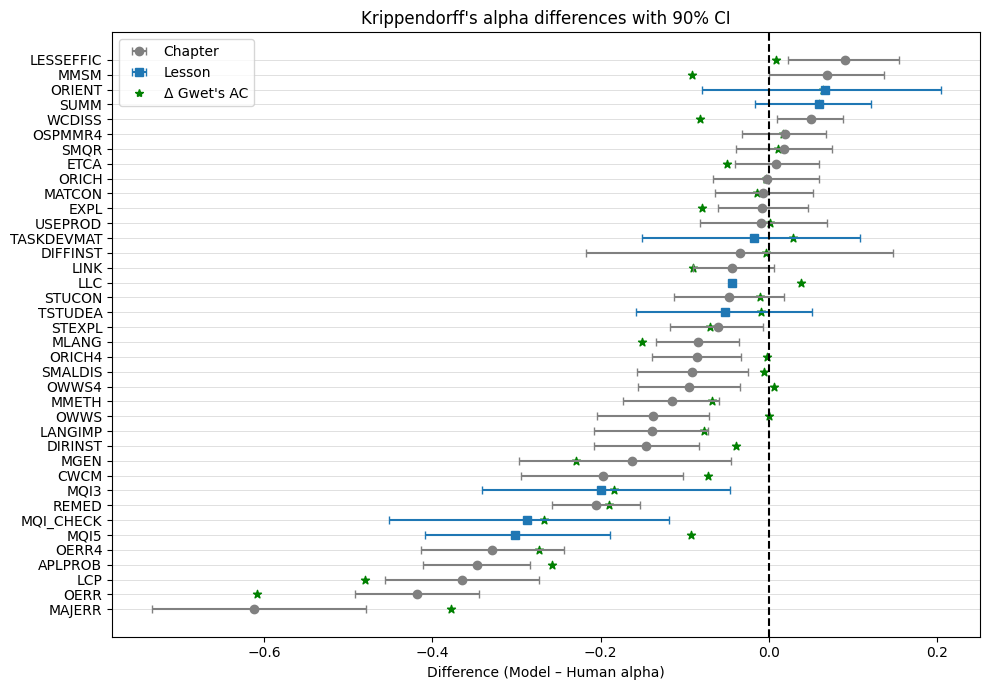

In [11]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

mask = diff_df["Variable"].isin(lesson_var)

# Segment level
ax.errorbar(
    diff_df.loc[~mask, "Difference"],
    y[~mask],
    xerr=[
        diff_df.loc[~mask, "Difference"] - diff_df.loc[~mask, "CI lower"],
        diff_df.loc[~mask, "CI upper"] - diff_df.loc[~mask, "Difference"],
    ],
    fmt="o",
    color="gray",
    capsize=3,
    label="Chapter"
)

# Lesson level
ax.errorbar(
    diff_df.loc[mask, "Difference"],
    y[mask],
    xerr=[
        diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
        diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
    ],
    fmt="s", 
    capsize=3,
    label="Lesson"
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
summary_table_chapter = (
    diff_df.assign(Group=np.where(mask, "Lesson", "Chapter"))
    .groupby("Group")
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

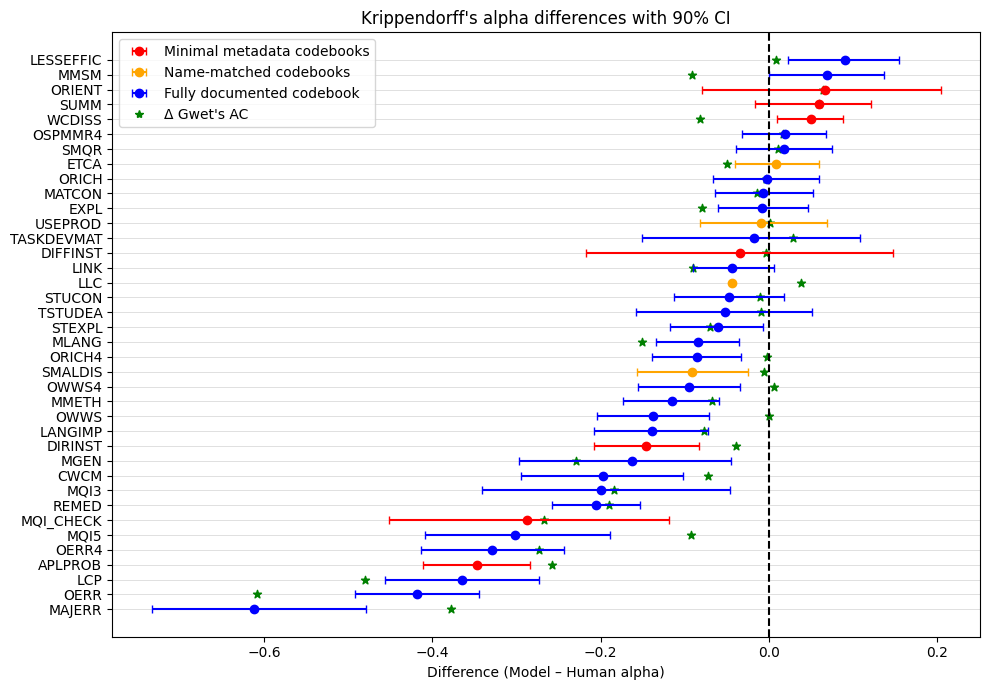

In [13]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(no_codebook)
mask2 = diff_df["Variable"].isin(adapted_codebook)
mask3 = ~(mask1 | mask2)

# Define a style for each list
groups = [
    (mask1, "Minimal metadata codebooks", "red"),
    (mask2, "Name-matched codebooks", "orange"),
    (mask3, "Fully documented codebook", "blue"),
]

for mask, label, color in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt='o',
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
group_col = np.select(
    [
        diff_df["Variable"].isin(no_codebook),
        diff_df["Variable"].isin(adapted_codebook)
    ],
    [
        "Minimal metadata codebooks",
        "Name-matched codebooks"
    ],
    default="Fully documented codebook"
)

order = [
    "Fully documented codebook",
    "Name-matched codebooks",
    "Minimal metadata codebooks"
]

summary_codebook = (
    diff_df.assign(Group=group_col)
    .assign(Group=lambda d: pd.Categorical(d["Group"], categories=order, ordered=True))
    .groupby("Group", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

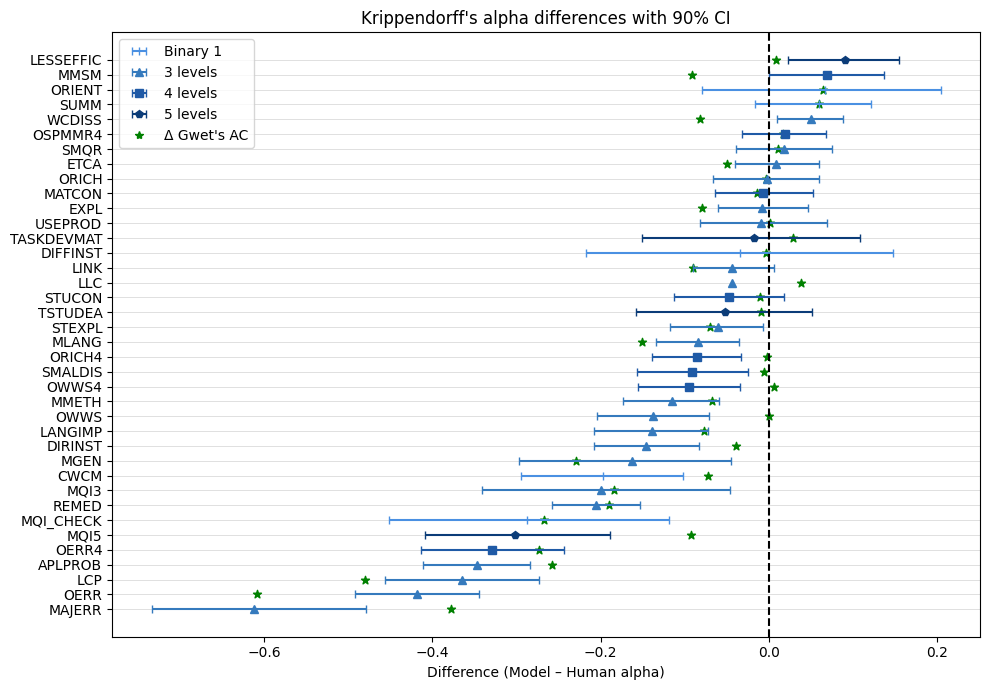

In [15]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(scl_binary)
mask2 = diff_df["Variable"].isin(scl_three)
mask3 = diff_df["Variable"].isin(scl_four)
mask4 = diff_df["Variable"].isin(scl_five)

# A style for each list
groups = [
    (mask1, "Binary 1", "#4a90e2", '|'),
    (mask2, "3 levels", "#357abd", "^"),
    (mask3, "4 levels", "#1f5aa6", "s"),
    (mask4, "5 levels", "#0b3c78", "p"),
]

for mask, label, color, marker in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt=marker,
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
scale_group = np.select(
    [
        diff_df["Variable"].isin(scl_binary),
        diff_df["Variable"].isin(scl_three),
        diff_df["Variable"].isin(scl_four),
        diff_df["Variable"].isin(scl_five),
    ],
    [
        "Binary",
        "3 levels",
        "4 levels",
        "5 levels",
    ],
)

order = ["Binary", "3 levels", "4 levels", "5 levels"]

summary_levels = (
    diff_df.assign(Scale=scale_group)
    .assign(Scale=lambda d: pd.Categorical(d["Scale"], categories=order))
    .groupby("Scale", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count"),
    )
    .round(4)
)

In [17]:
big_summary = pd.concat([summary_table_chapter, summary_codebook, summary_levels], axis=0).reset_index(names="Grouping")
big_summary

,Grouping,Mean_Difference,Mean_Delta_AC,Mean_Human_alpha,N
0,Chapter,-0.1164,-0.1094,0.3427,30
1,Lesson,-0.0971,-0.0453,0.3033,8
2,Fully documented codebook,-0.1294,-0.1149,0.3439,27
3,Name-matched codebooks,-0.0340,-0.0038,0.3767,4
4,Minimal metadata codebooks,-0.0913,-0.0753,0.2735,7
5,Binary,-0.0786,-0.0439,0.2603,5
6,3 levels,-0.1440,-0.1422,0.3185,21
7,4 levels,-0.0710,-0.0469,0.4063,8
8,5 levels,-0.0704,-0.0160,0.3669,4


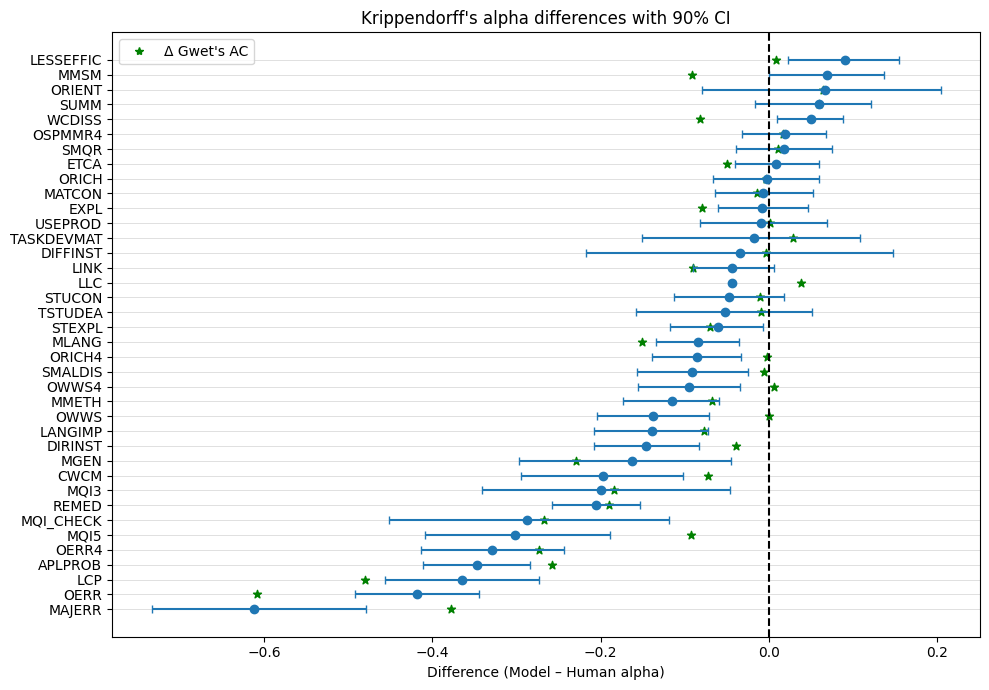

In [18]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    diff_df["Difference"],
    y,
    xerr=[diff_df["Difference"] - diff_df["CI lower"],
          diff_df["CI upper"] - diff_df["Difference"]],
    fmt="o",
    capsize=3
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

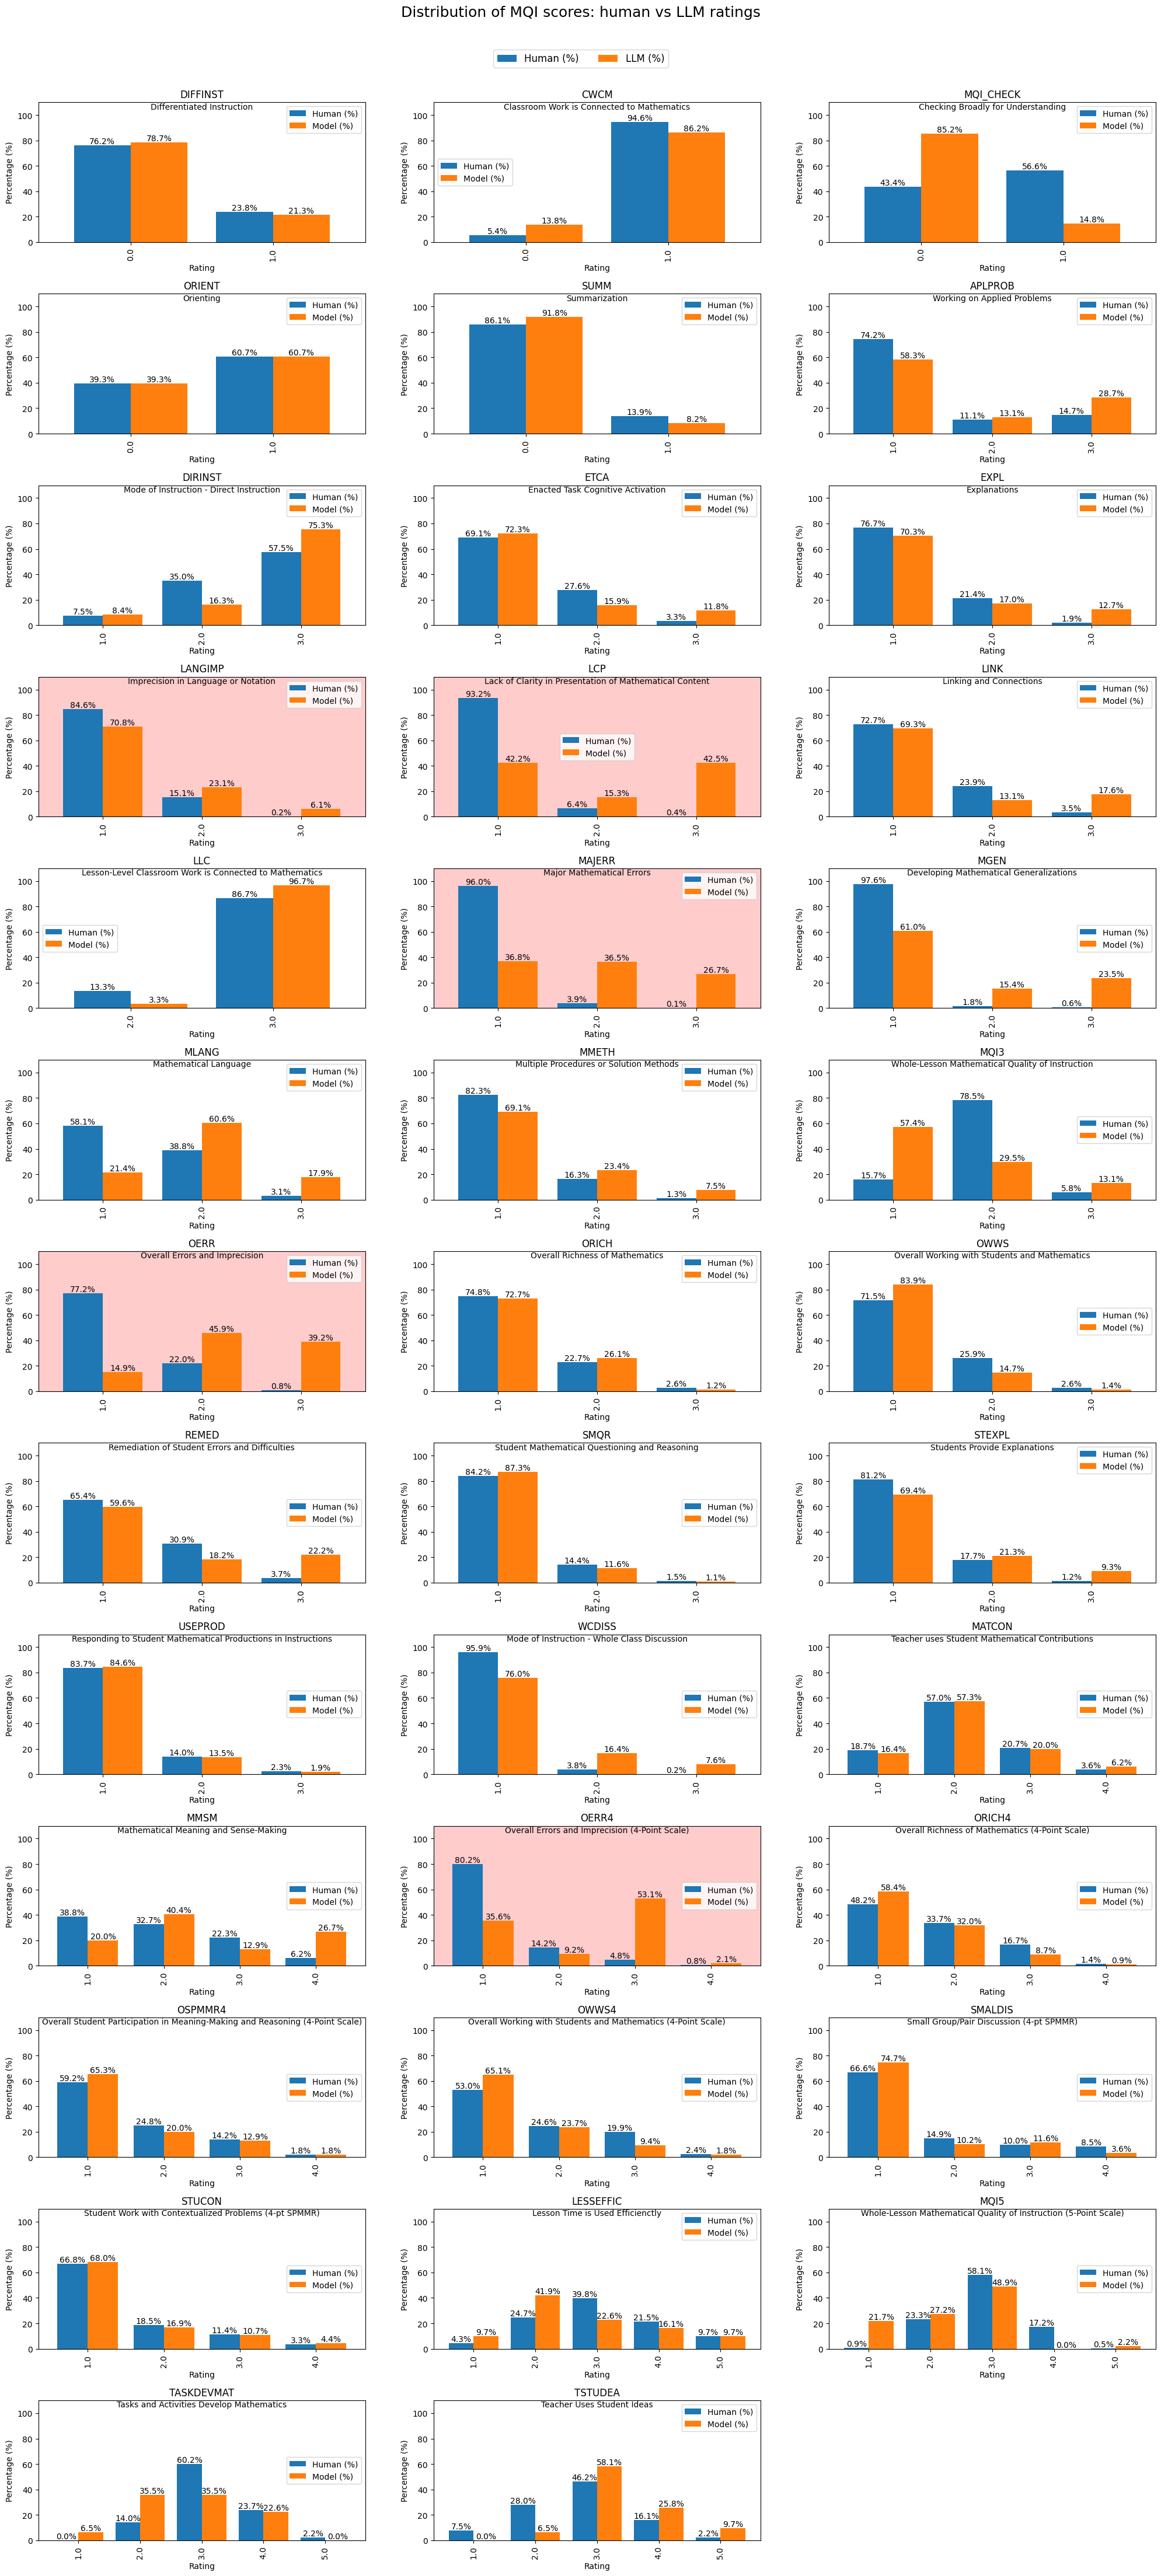

In [19]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(20, 45))
axes = axes.flatten()
all_vars = scl_binary + scl_three + scl_four + scl_five

for (var, ax) in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    humans = df[rater_cols].stack().dropna()
    model = df["rating"]

    counts_h = humans.value_counts(normalize=True).sort_index() * 100
    counts_m = model.value_counts(normalize=True).sort_index() * 100

    idx = sorted(set(counts_h.index) | set(counts_m.index))
    plot_df = pd.DataFrame({
        "Human (%)": counts_h,
        "Model (%)": counts_m
    })

    plot_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(var)
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim([0, 110])
    if var in reversed_var:
        ax.set_facecolor("#ffcccc")

    # Display percent values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=10)

fig.suptitle("Distribution of MQI scores: human vs LLM ratings", fontsize=18)
fig.legend(
    ["Human (%)", "LLM (%)"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    fontsize=12
)

# Hide the useless axes
for ax in axes[len(all_vars):]:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("kripp_diff_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

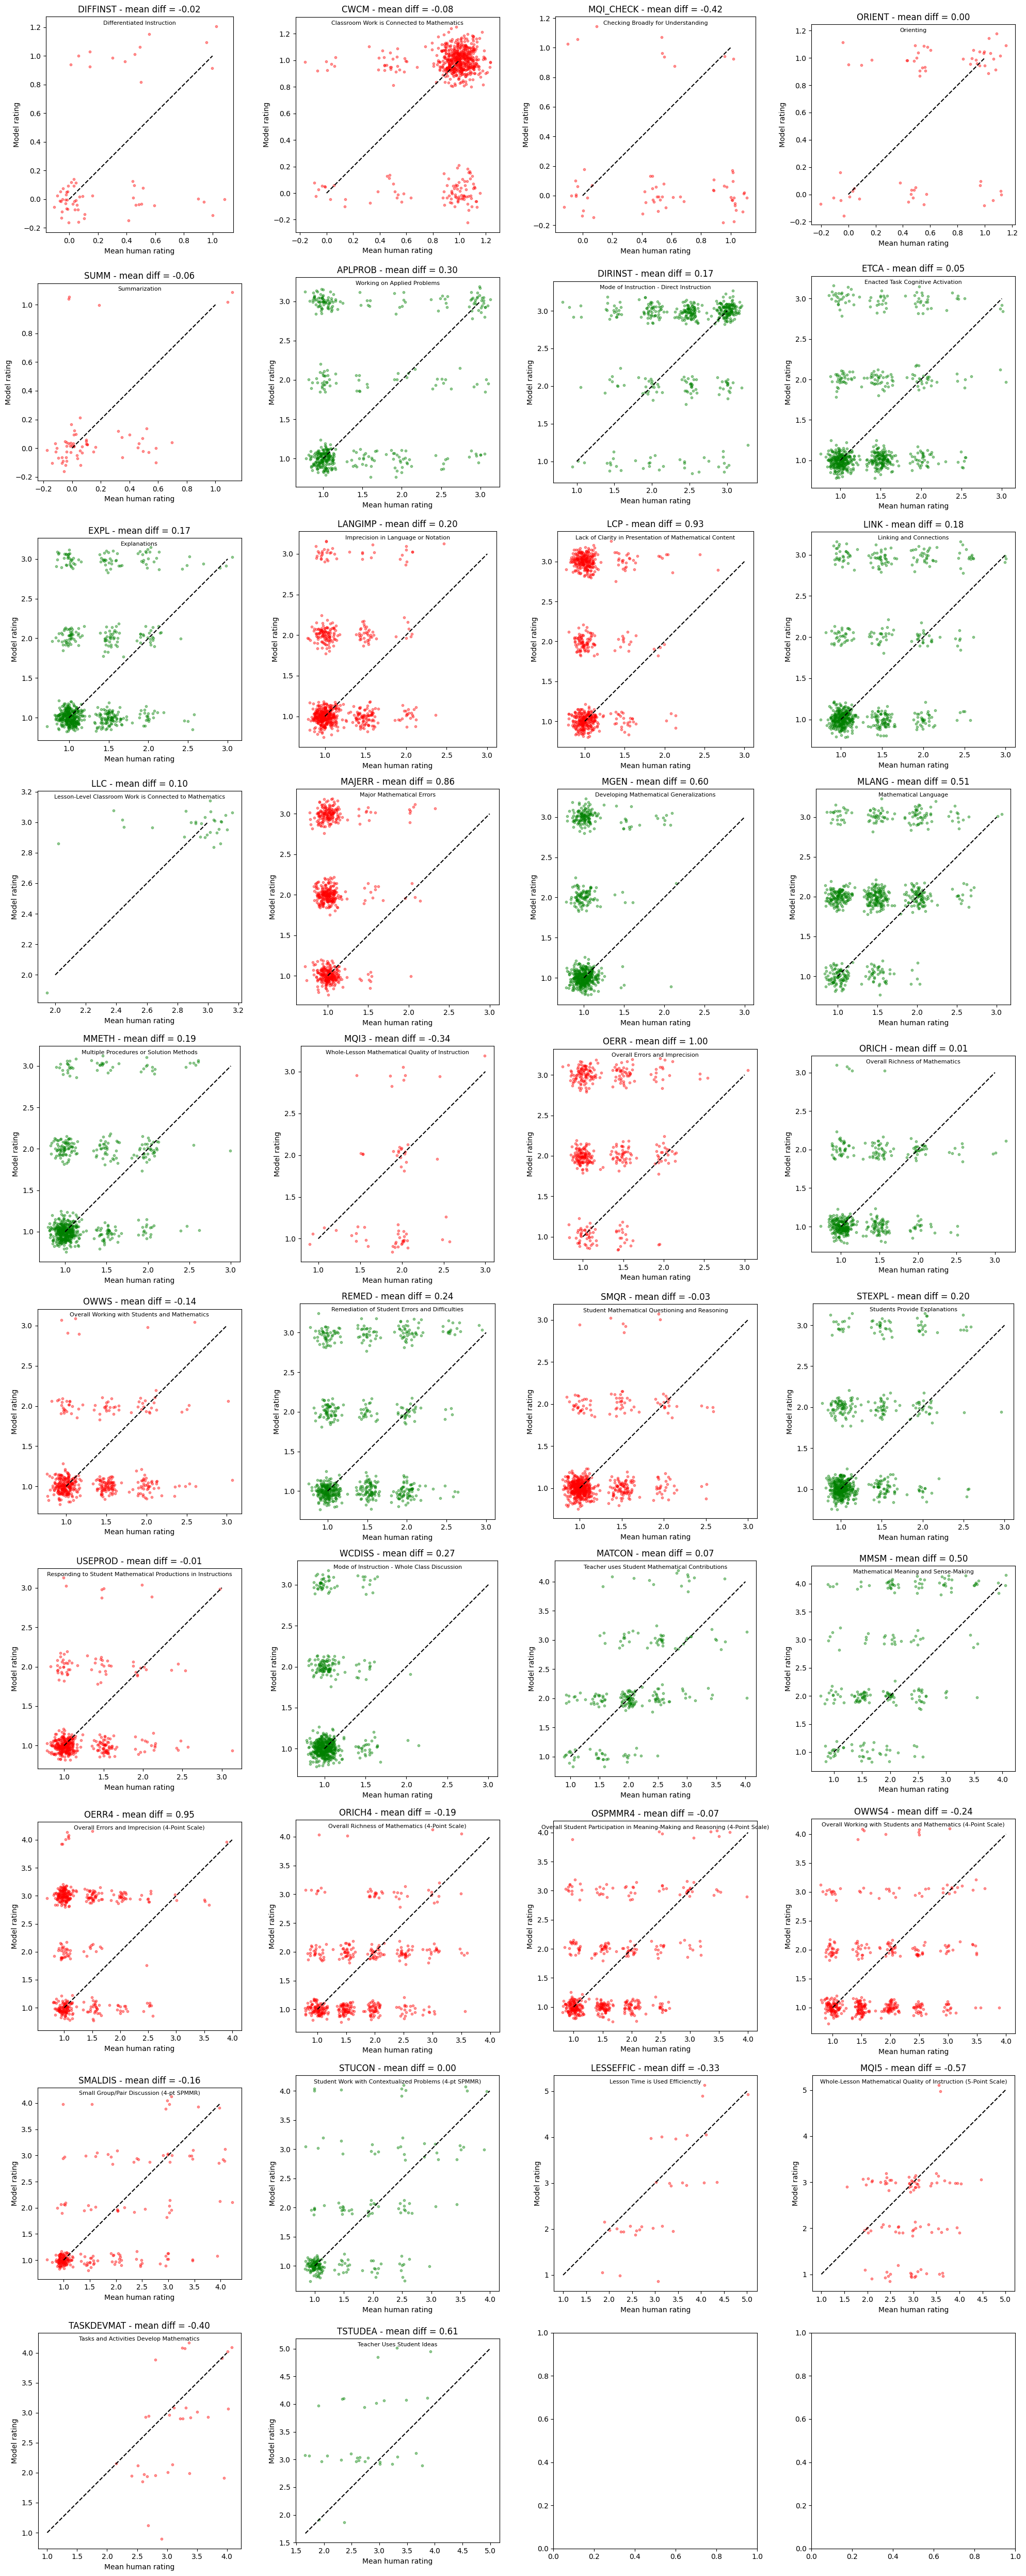

In [20]:
fig, axes = plt.subplots(ncols=4, nrows=10, figsize=(20, 50))
axes = axes.flatten()

for var, ax in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    # Human mean per item
    human_mean = df[rater_cols].mean(axis=1, skipna=True)
    model = df["rating"]
    diff_mean = (model - human_mean).mean()
    if var not in reversed_var:
        colors = "green" if diff_mean > 0 else "red"
    else:
         colors = "red" if diff_mean > 0 else "green"

    # Jitter
    jitter_x = np.random.normal(0, 0.08, size=len(human_mean))
    jitter_y = np.random.normal(0, 0.08, size=len(model))

    # Scatter
    ax.scatter(
        human_mean + jitter_x,
        model + jitter_y,
        c=colors,
        alpha=0.4,
        s=10
    )

    # Diagonale y = x
    min_val = min(human_mean.min(), model.min())
    max_val = max(human_mean.max(), model.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

    ax.set_title(f"{var} - mean diff = {diff_mean:.2f}")
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes, fontsize=8)
    ax.set_xlabel("Mean human rating")
    ax.set_ylabel("Model rating")
    ax.set_aspect("equal", "box")

plt.tight_layout()
plt.show()

# Kendall tau

In [21]:
huge_df = pd.DataFrame()
for var in all_vars:
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    human_mean = df[rater_cols].mean(axis=1, skipna=True)
    model = df["rating"]

    df_per_OBSID = pd.DataFrame({
        "NCTETID": df["NCTETID"],
        "OBSID": df["OBSID"],
        "variable": var,
        "human_mean": human_mean,
        "model": model
    })
    my_dico[var]["df_per_OBSID"] = df_per_OBSID
    huge_df = pd.concat([huge_df, df_per_OBSID], ignore_index=True)

In [22]:
my_dico["APLPROB"]["df_per_OBSID"]

,NCTETID,OBSID,variable,human_mean,model
0,11043,1084,APLPROB,1.0,3
1,11043,1084,APLPROB,1.0,1
2,11043,1084,APLPROB,1.0,3
3,11043,1084,APLPROB,1.0,3
4,11043,1084,APLPROB,1.0,3
...,...,...,...,...,...
424,14098,910,APLPROB,2.0,1
425,14098,910,APLPROB,1.5,1
426,14098,910,APLPROB,1.5,2
427,14098,910,APLPROB,1.5,1


In [23]:
huge_df

,NCTETID,OBSID,variable,human_mean,model
0,11043,1084,DIFFINST,0.000000,0.0
1,11043,22,DIFFINST,0.500000,0.0
2,11043,2370,DIFFINST,0.000000,0.0
3,11043,2593,DIFFINST,0.500000,0.0
4,11043,2765,DIFFINST,0.500000,0.0
...,...,...,...,...,...
14885,14093,4413,TSTUDEA,2.666667,4.0
14886,14098,4057,TSTUDEA,2.333333,3.0
14887,14098,4198,TSTUDEA,1.666667,3.0
14888,14098,4538,TSTUDEA,2.666667,3.0


## Correspondance between humans ratings and LLM ratings at the variable level

In [24]:
result_per_OBSID_per_variable = []

for var, g in huge_df.groupby("variable"):
    # Group by OBSID
    g_obs = (
        g.groupby("OBSID")[["human_mean", "model"]]
        .mean()
        .dropna()
    )
    
    # Remove NaN
    g_obs = g_obs[["human_mean", "model"]].dropna()

    # Calculate tau
    tau, p = kendalltau(g_obs["human_mean"], g_obs["model"])
    result_per_OBSID_per_variable.append({"variable": var, "kendall_tau": tau, "p_value": p})

result_per_OBSID_per_variable = pd.DataFrame(result_per_OBSID_per_variable)

result_per_OBSID_per_variable

,variable,kendall_tau,p_value
0,APLPROB,0.213414,2.353391e-02
1,CWCM,0.313539,2.623644e-04
2,DIFFINST,0.343144,5.855440e-03
3,DIRINST,0.330389,3.537736e-04
4,ETCA,0.333270,9.473204e-06
5,EXPL,0.263223,4.624395e-04
6,LANGIMP,0.032758,6.656796e-01
7,LCP,-0.058727,4.571023e-01
8,LESSEFFIC,0.646834,7.539402e-06
9,LINK,0.435963,6.599097e-09


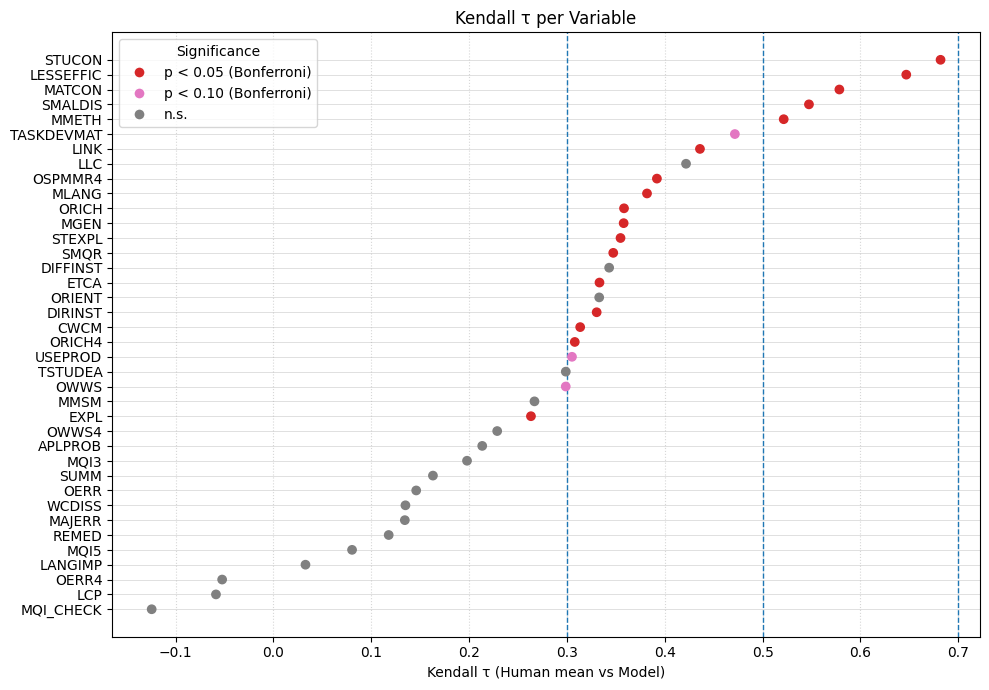

In [25]:
df_plot = result_per_OBSID_per_variable.sort_values("kendall_tau").reset_index(drop=True)

y = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(10, 7))

# Color according to corrected significance
colors = np.where(df_plot["p_value"] < (0.05/len(df_plot)), "tab:red", np.where(df_plot["p_value"] < (0.1/len(df_plot)), "tab:pink", "gray"))

ax.scatter(
    df_plot["kendall_tau"],
    y,
    c=colors,
    zorder=3
)
for x in [0.3, 0.5, 0.7]:
    ax.axvline(x, linestyle="--", linewidth=1)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
    
ax.set_yticks(y)
ax.set_yticklabels(df_plot["variable"])
ax.set_xlabel("Kendall τ (Human mean vs Model)")
ax.set_title("Kendall τ per Variable")

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='tab:red', markersize=8,
           label='p < 0.05 (Bonferroni)'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='tab:pink', markersize=8,
           label='p < 0.10 (Bonferroni)'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray', markersize=8,
           label='n.s.')
]

ax.legend(handles=legend_elements, title="Significance")

ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Correspondance between humans ratings and LLM ratings at the course level

In [26]:
def get_min_max(variable):
    if variable in scl_binary:
        return (0, 1)
    elif variable in scl_three:
        return (1, 3)
    elif variable in scl_four:
        return (1, 4)
    elif variable in scl_five:
        return (1, 5)
    else:
        return (None, None)
    
def normalize_value(row, column):
    var = row["variable"]
    min_val, max_val = get_min_max(var)
    
    return (row[column] - min_val) / (max_val - min_val)

In [27]:
composite_per_OBSID = (
    huge_df
    .groupby(["variable", "NCTETID", "OBSID"], as_index=False)[["human_mean", "model"]]
    .mean()
    .dropna(subset=["human_mean", "model"])
)

# Min-max scaling of the scores per variable
composite_per_OBSID["normalized_human"] = composite_per_OBSID.apply(
    lambda row: normalize_value(row, "human_mean"),
    axis=1
)
composite_per_OBSID["normalized_model"] = composite_per_OBSID.apply(
    lambda row: normalize_value(row, "model"),
    axis=1
)

# Correction for variables where higher is worse (reverse the scale)
reversed_var = ["LANGIMP", "LCP", "MAJERR", "OERR", "OERR4"]
mask = composite_per_OBSID["variable"].isin(reversed_var)

composite_per_OBSID.loc[mask, "normalized_human"] = (
    1 - composite_per_OBSID.loc[mask, "normalized_human"]
)

composite_per_OBSID.loc[mask, "normalized_model"] = (
    1 - composite_per_OBSID.loc[mask, "normalized_model"]
)

composite_per_OBSID

,variable,NCTETID,OBSID,human_mean,model,normalized_human,normalized_model
0,APLPROB,11043,22,1.300000,1.400000,0.150000,0.200000
1,APLPROB,11043,577,1.125000,1.250000,0.062500,0.125000
2,APLPROB,11043,1084,1.000000,2.111111,0.000000,0.555556
3,APLPROB,11043,2370,2.937500,2.750000,0.968750,0.875000
4,APLPROB,11043,2593,1.000000,2.714286,0.000000,0.857143
...,...,...,...,...,...,...,...
2537,WCDISS,14098,2737,1.062500,1.375000,0.031250,0.187500
2538,WCDISS,14098,4057,1.000000,1.000000,0.000000,0.000000
2539,WCDISS,14098,4198,1.071429,1.142857,0.035714,0.071429
2540,WCDISS,14098,4538,1.000000,1.333333,0.000000,0.166667


In [28]:
course_means = (
    composite_per_OBSID
    .dropna(subset=["normalized_human", "normalized_model"])
    .groupby(["NCTETID", "OBSID"], as_index=False)[["normalized_human", "normalized_model"]]
    .mean()
    .rename(columns={
        "normalized_human": "course_mean_human",
        "normalized_model": "course_mean_model"
    })
)

course_means

,NCTETID,OBSID,course_mean_human,course_mean_model
0,11043,22,0.472115,0.355769
1,11043,577,0.522837,0.634615
2,11043,1084,0.435363,0.389957
3,11043,2370,0.459005,0.392473
4,11043,2593,0.364631,0.462366
...,...,...,...,...
87,14098,2737,0.466398,0.499328
88,14098,4057,0.336996,0.338828
89,14098,4198,0.369505,0.311050
90,14098,4538,0.313034,0.414530


In [29]:
tau, p = kendalltau(
    course_means["course_mean_human"],
    course_means["course_mean_model"]
)

print(f"Kendall tau: {tau:.3f}")
print(f"p-value: {p}")
print("n:", len(course_means))

Kendall tau: 0.298
p-value: 2.6784888320952028e-05
n: 92


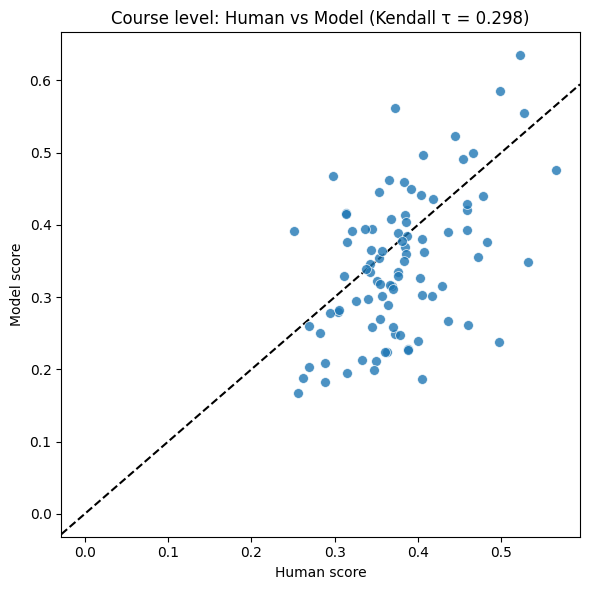

In [30]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=course_means["course_mean_human"], 
    y=course_means["course_mean_model"],
    data=course_means,
    s=50,
    alpha=0.8,
    zorder=3
)

plt.xlabel("Human score")
plt.ylabel("Model score")
plt.title(f"Course level: Human vs Model (Kendall τ = {tau:.3f})")
plt.axline((0,0), slope=1, linestyle="--", color="black")  # Identity line
plt.tight_layout()
plt.show()

In [31]:
# Core transformation (Edwards, de Jong, Ferguson)
def kendall_pair_endpoints(x, y):
    """
    Build transformed endpoints for all i<j pairs as in the preprint:
    - take pairwise vectors (dx, dy)
    - translate so the 'smaller x' point is at the origin (tie -> smaller y)
    - map vector to polar (r, theta) then double the angle: (r*cos(2θ), r*sin(2θ))

    Returns
    -------
    Xt, Yt : transformed endpoints (arrays, length n_pairs)
    dx, dy : oriented original differences after the 'smaller-to-origin' rule
    diss   : dissimilarity proxy |dx - dy| (as in the paper's idea)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    # all pairs i<j
    I, J = np.triu_indices(n, k=1)

    dx0 = x[J] - x[I]
    dy0 = y[J] - y[I]

    # "smaller x to origin" (if tie in x, use smaller y)
    swap = (dx0 < 0) | ((dx0 == 0) & (dy0 < 0))
    dx = dx0.copy()
    dy = dy0.copy()
    dx[swap] *= -1
    dy[swap] *= -1

    r = np.hypot(dx, dy)
    theta = np.arctan2(dy, dx)              # [-pi, pi]
    Xt = r * np.cos(2 * theta)
    Yt = r * np.sin(2 * theta)

    diss = np.abs(dx - dy)                  # "dissimilarity" style quantity
    return Xt, Yt, dx, dy, diss


# Endpoint plot

def plot_tau_endpoints(x, y, x_name="x", y_name="y", with_vectors=False, title=None):
    Xt, Yt, dx, dy, diss = kendall_pair_endpoints(x, y)

    fig, ax = plt.subplots()
    ax.axhline(0, linewidth=1, color="black", linestyle="--")
    ax.axvline(0, linewidth=1, color="black", linestyle="--")

    if with_vectors:
        # draw from origin to each endpoint (can be cluttered for large n)
        for xt, yt in zip(Xt, Yt):
            ax.plot([0, xt], [0, yt], linewidth=0.5)

    ax.scatter(Xt, Yt, s=10)

    # Center around the origin (0, 0)
    max_range = max(
        np.max(np.abs(Xt)),
        np.max(np.abs(Yt))
    ) + 0.02
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Transformed pairwise relation of {x_name}")
    ax.set_ylabel(f"Transformed pairwise relation of {y_name}")

    if title:
        ax.set_title(title)
    plt.show()

# Dissimilarity scatter

def plot_tau_dissimilarity(x, y, x_name="x", y_name="y", title=None):
    Xt, Yt, dx, dy, diss = kendall_pair_endpoints(x, y)

    fig, ax = plt.subplots()
    ax.axhline(0, linewidth=1, color="black", linestyle="--")
    ax.axvline(0, linewidth=1, color="black", linestyle="--")

    sc = ax.scatter(Xt, Yt, s=10, c=diss)  # color encodes dissimilarity
    plt.colorbar(sc, ax=ax, label="|Δx - Δy|")

    # Center around the origin (0, 0)
    max_range = max(
        np.max(np.abs(Xt)),
        np.max(np.abs(Yt))
    ) + 0.02
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Transformed pairwise relation of {x_name}")
    ax.set_ylabel(f"Transformed pairwise relation of {y_name}")
    if title:
        ax.set_title(title)
    plt.show()


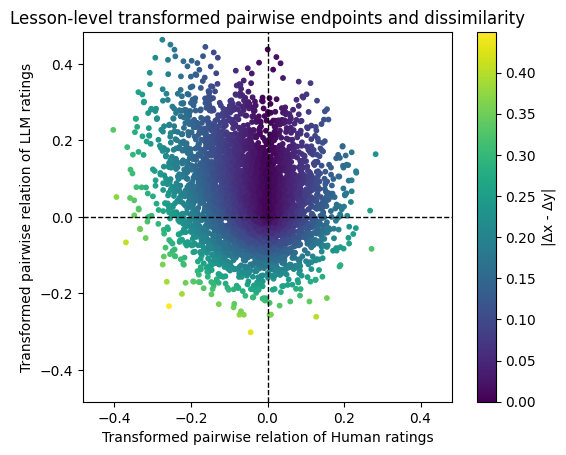

In [32]:
# Course-level (n≈92) example:
# df must have 1 row per course
x_course = course_means["course_mean_human"].to_numpy()
y_course = course_means["course_mean_model"].to_numpy()
plot_tau_dissimilarity(x_course, y_course,
                       x_name="Human ratings",
                       y_name="LLM ratings",
                       title="Lesson-level transformed pairwise endpoints and dissimilarity")

# Correspondance between humans ratings and LLM ratings at the teacher level

In [33]:
teacher_means = (
    course_means
    .dropna(subset=["course_mean_human", "course_mean_model"])
    .groupby("NCTETID", as_index=False)[["course_mean_human", "course_mean_model"]]
    .mean()
)

x = teacher_means["course_mean_human"].to_numpy()
y = teacher_means["course_mean_model"].to_numpy()

tau_teacher, p_teacher = kendalltau(x, y)
print(f"Kendall tau: {tau_teacher:.3f}")
print(f"p-value: {p_teacher}")
print("n:", len(teacher_means))

Kendall tau: 0.556
p-value: 0.02860945767195767
n: 10


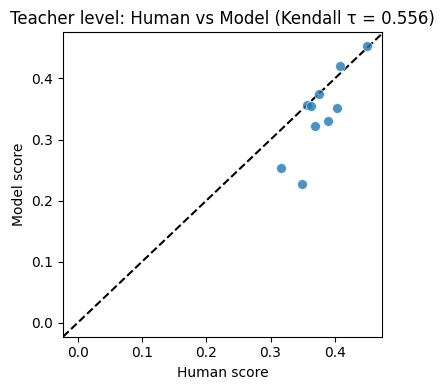

In [34]:
plt.figure(figsize=(4,4))
sns.scatterplot(
    x=teacher_means["course_mean_human"], 
    y=teacher_means["course_mean_model"],
    data=course_means,
    s=50,
    alpha=0.8,
    zorder=3
)

plt.xlabel("Human score")
plt.ylabel("Model score")
plt.title(f"Teacher level: Human vs Model (Kendall τ = {tau_teacher:.3f})")
plt.axline((0,0), slope=1, linestyle="--", color="black")  # Identity line
plt.tight_layout()
plt.show()

In [35]:
# Permutation test at the teacher level (H0: independence)
def permutation_test_kendall_tau(x, y, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    taus = np.empty(n_perm)

    for b in range(n_perm):
        y_perm = rng.permutation(y)  # break association
        taus[b] = kendalltau(x, y_perm).statistic

    p_two_sided = np.mean(np.abs(taus) >= np.abs(tau_teacher))
    return taus, p_two_sided

In [36]:
taus_perm, p_perm = permutation_test_kendall_tau(x, y, n_perm=10000, seed=42)

print(f"Kendall tau: {tau_teacher:.3f}")
print(f"p-value two-sided: {p_perm}")
print("n:", len(teacher_means))

Kendall tau: 0.556
p-value two-sided: 0.0293
n: 10


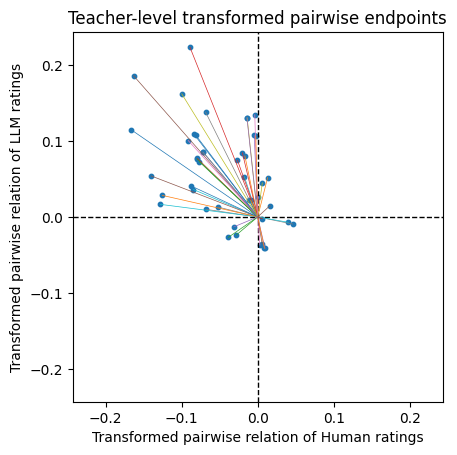

In [37]:
# Teacher-level (n=10):
x_teacher = teacher_means["course_mean_human"].to_numpy()
y_teacher = teacher_means["course_mean_model"].to_numpy()
plot_tau_endpoints(x_teacher, y_teacher,
                   x_name="Human ratings",
                   y_name="LLM ratings",
                   title="Teacher-level transformed pairwise endpoints",
                   with_vectors=True)

Visual inspection of the transformed Kendall τ plot suggests that, for many pairwise comparisons, differences between teachers appear larger in the LLM scores (y) than in the human scores (x). This pattern may indicate that the LLM produces sharper between-teacher differentiation. However, this observation should be interpreted cautiously, as amplified differences do not necessarily imply reduced noise or improved ranking accuracy.

In [38]:
teacher_means

,NCTETID,course_mean_human,course_mean_model
0,11043,0.450432,0.452845
1,11058,0.389956,0.329927
2,12024,0.408368,0.420077
3,12025,0.403372,0.351654
4,14012,0.315585,0.253800
5,14043,0.375829,0.375013
6,14079,0.348381,0.227275
7,14085,0.356681,0.356375
8,14093,0.369312,0.321893
9,14098,0.362646,0.355211
